**Load** **data**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


def load_data(file_path):
    df = pd.read_csv(file_path)
    print("Dataset Initial Shape:", df.shape)
    print("\nFirst few rows of the dataset:")
    print(df.head())

    return df

**Data cleaning and Preprocessing**

In [16]:
def clean_data(df):
    print("\n=== Data Cleaning Report ===")

    print("\nMissing Values:")
    print(df.isnull().sum())

    df_cleaned = df.drop_duplicates()
    print(f"\nDuplicates removed: {len(df) - len(df_cleaned)} rows")

    numeric_columns = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                      'Previous_Scores', 'Tutoring_Sessions',
                      'Physical_Activity', 'Exam_Score']

    for col in numeric_columns:
        if df_cleaned[col].isnull().any():
            df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

    categorical_columns = ['Parental_Involvement', 'Access_to_Resources',
                         'Extracurricular_Activities', 'Motivation_Level',
                         'Internet_Access', 'Family_Income', 'Teacher_Quality',
                         'School_Type', 'Peer_Influence', 'Learning_Disabilities',
                         'Parental_Education_Level', 'Distance_from_Home', 'Gender']

    for col in categorical_columns:
        if df_cleaned[col].isnull().any():
            df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

    return df_cleaned

**Feature Encoding**

In [17]:
def preprocess_data(df):
    le = LabelEncoder()

    categorical_columns = ['Parental_Involvement', 'Access_to_Resources',
                         'Extracurricular_Activities', 'Motivation_Level',
                         'Internet_Access', 'Family_Income', 'Teacher_Quality',
                         'School_Type', 'Peer_Influence', 'Learning_Disabilities',
                         'Parental_Education_Level', 'Distance_from_Home', 'Gender']

    df_encoded = df.copy()
    for col in categorical_columns:
        df_encoded[col] = le.fit_transform(df_encoded[col])

    scaler = StandardScaler()
    numeric_columns = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                      'Previous_Scores', 'Tutoring_Sessions',
                      'Physical_Activity']

    df_encoded[numeric_columns] = scaler.fit_transform(df_encoded[numeric_columns])

    return df_encoded

**EDA**

In [18]:
def perform_eda(df):
    print("\n=== Exploratory Data Analysis ===")

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='Exam_Score')
    plt.title('Distribution of Exam Scores')

    num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Physical_Activity']
    df[num_cols].hist(bins=10, figsize=(15, 10))
    plt.suptitle('Histograms of Numeric Variables')
    plt.show()

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score')
    plt.title('Hours Studied vs Exam Score')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    sns.boxplot(data=df, x='School_Type', y='Exam_Score', ax=axes[0,0])
    axes[0,0].set_title('School Type vs Exam Score')

    sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', ax=axes[0,1])
    axes[0,1].set_title('Parental Involvement vs Exam Score')

    sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score', ax=axes[1,0])
    axes[1,0].set_title('Motivation Level vs Exam Score')

    sns.boxplot(data=df, x='Gender', y='Exam_Score', ax=axes[1,1])
    axes[1,1].set_title('Gender vs Exam Score')

    plt.tight_layout()
    plt.show()

    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(12, 8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.show()

Dataset Initial Shape: (6607, 20)

First few rows of the dataset:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  T

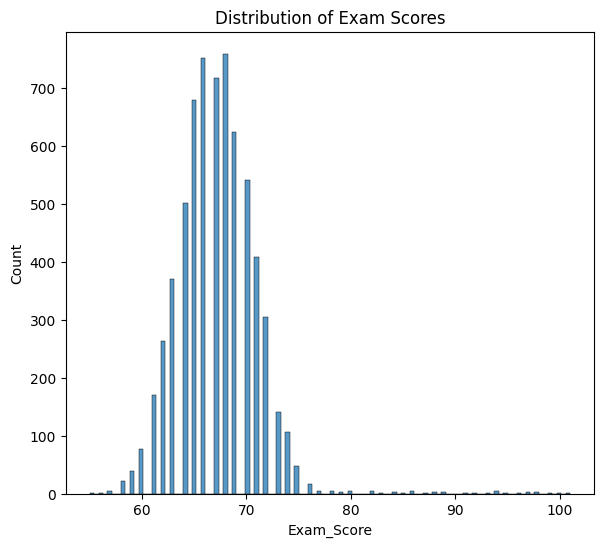

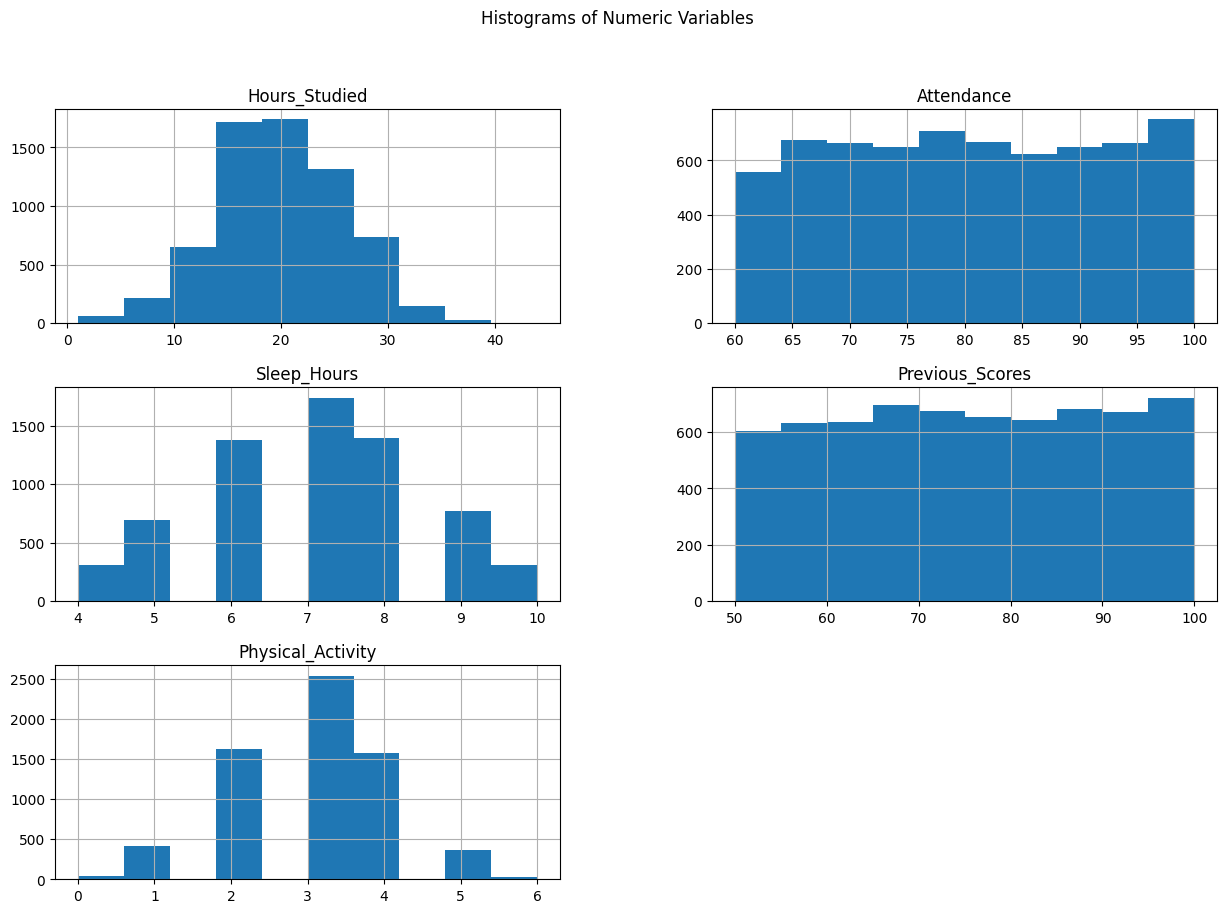

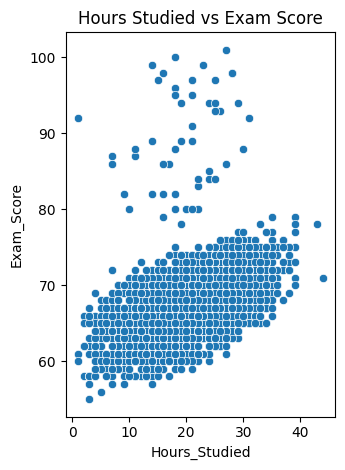

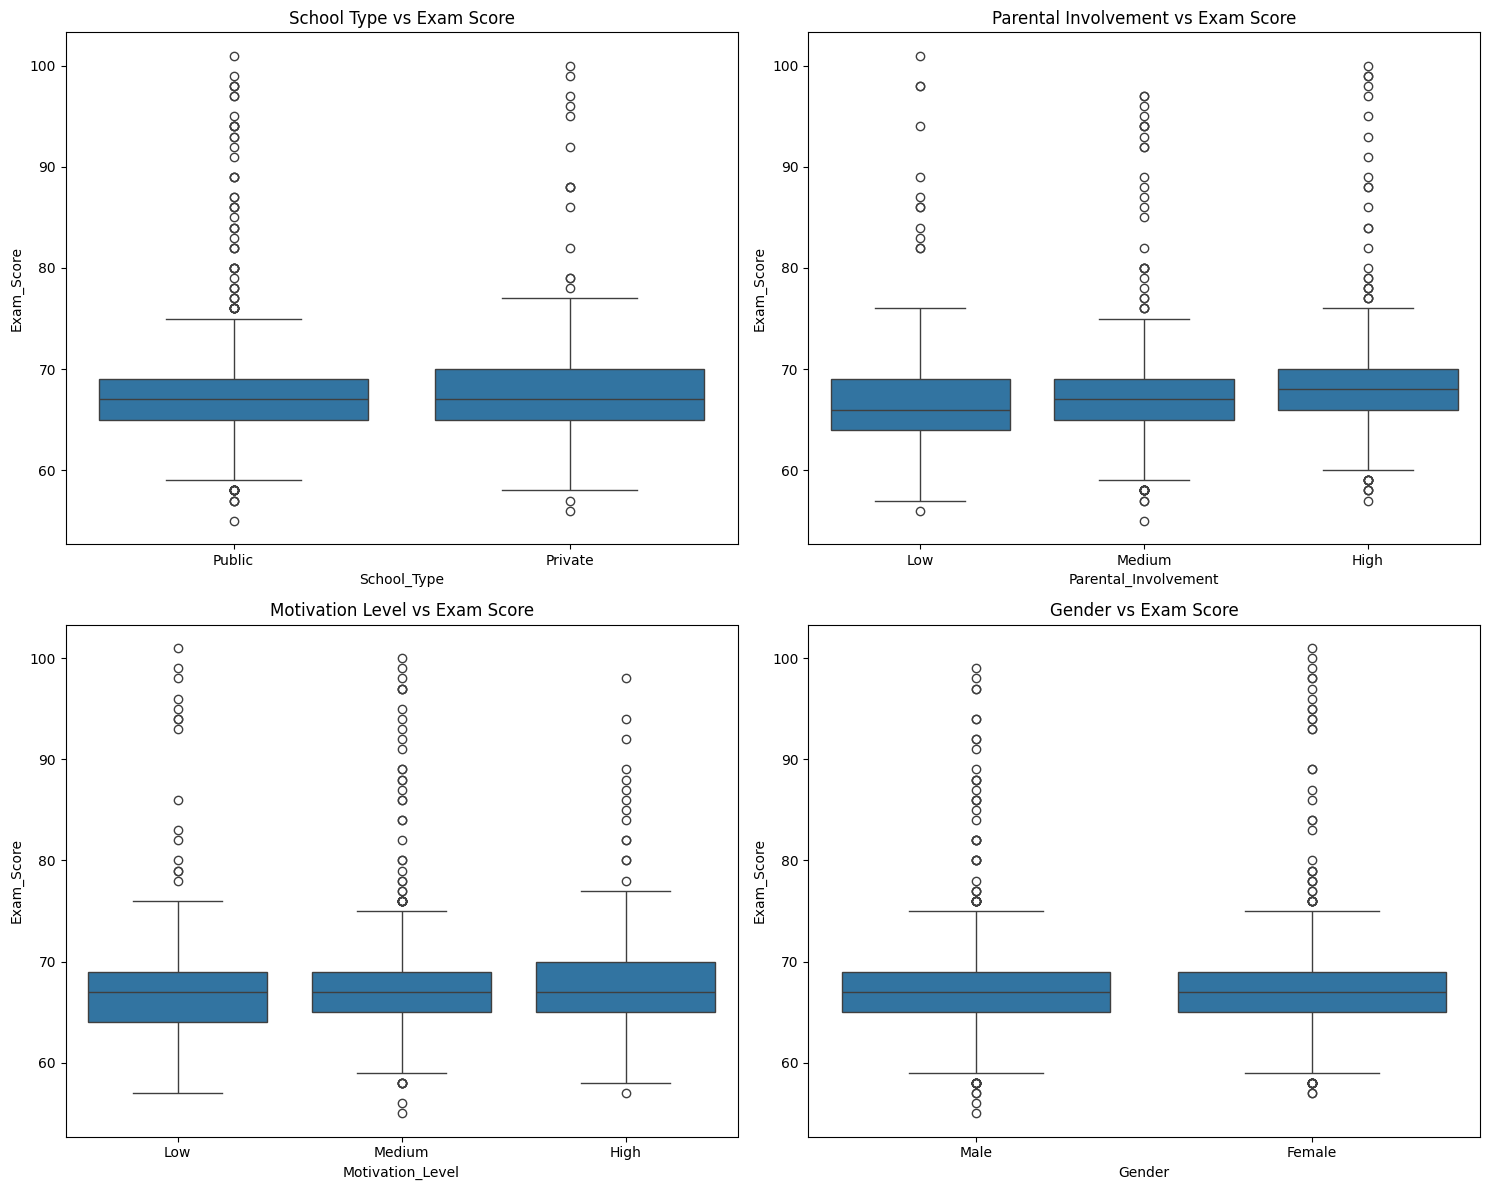

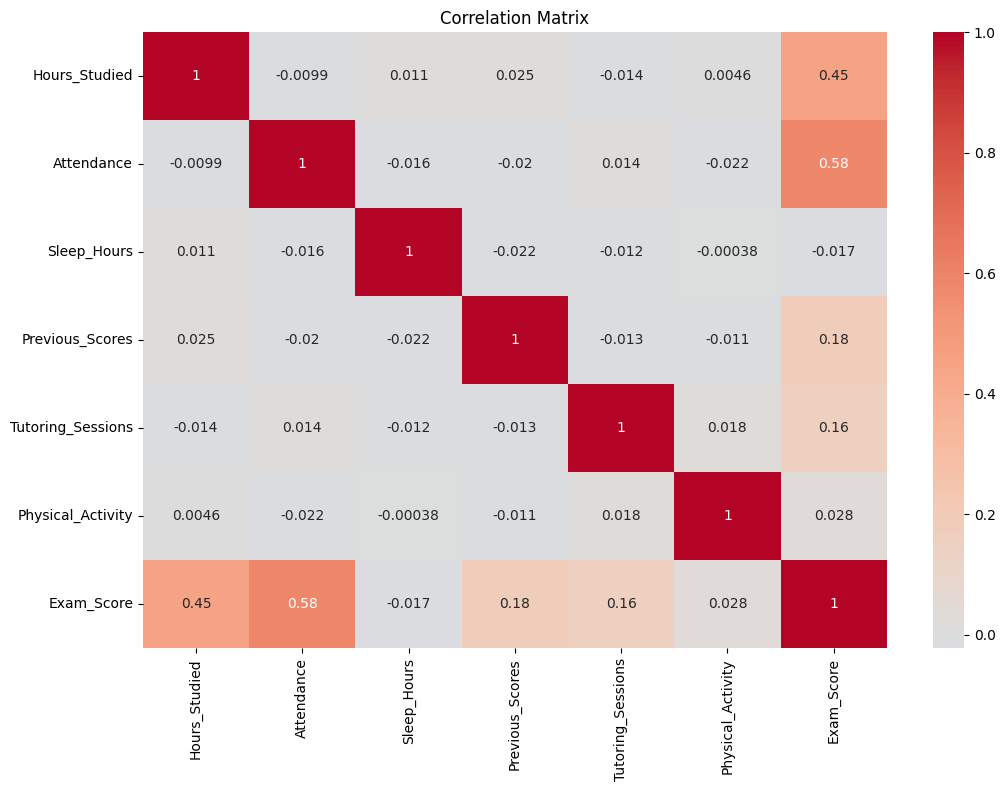

Reduced dimensionality to 16 components.

=== Model Performance ===
Mean Absolute Error (MAE): 1.07
Mean Squared Error (MSE): 4.50
Root Mean Squared Error (RMSE): 2.12
R² Score: 0.68

Retraining the model with full features (no dimensionality reduction).

=== Model Performance ===
Mean Absolute Error (MAE): 1.02
Mean Squared Error (MSE): 4.40
Root Mean Squared Error (RMSE): 2.10
R² Score: 0.69


In [19]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def dimensionality_reduction(X, n_components=0.95):
    pca = PCA(n_components=n_components)  # Preserve 95% variance
    X_pca = pca.fit_transform(X)
    print(f"Reduced dimensionality to {X_pca.shape[1]} components.")
    return X_pca

def model_training_and_evaluation(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n=== Model Performance ===")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    return model, r2

if __name__ == "__main__":
    file_path = 'StudentPerformanceFactors.csv'

    df = load_data(file_path)
    df_cleaned = clean_data(df)
    perform_eda(df_cleaned)
    df_encoded = preprocess_data(df_cleaned)

    X = df_encoded.drop(columns=['Exam_Score'])
    y = df_encoded['Exam_Score']

    X_pca = dimensionality_reduction(X)

    model, r2 = model_training_and_evaluation(X_pca, y)

    if r2 < 0.8:
        print("\nRetraining the model with full features (no dimensionality reduction).")
        model_training_and_evaluation(X, y)
